# Семинар 6 - Классические алгоритмы сегментации изображения и обнаружения объектов

**Данный семинар содержит ДЗ**

***

In [1]:
import random as rng

import cv2
import numpy as np
import matplotlib.pyplot as plt

rng.seed(12345)

In [2]:
# !mkdir -p data
# !wget https://github.com/opencv/opencv/raw/4.x/samples/data/cards.png -O data/cards.png

# Image Segmentation with Distance Transform and Watershed Algorithm

Источник - https://docs.opencv.org/3.4/d2/dbd/tutorial_distance_transform.html

В этом семинаре вы узнаете, как:

- Использовать `cv2.filter2D`, чтобы выполнить фильтрацию Лапласа для повышения резкости изображения.
- Использовать `cv2.distanceTransform`, чтобы получить производное представление двоичного изображения, где значение каждого пикселя заменяется его расстоянием до ближайшего пикселя фона.
- Использовать `cv2.watershed`, чтобы изолировать объекты на изображении от фона.

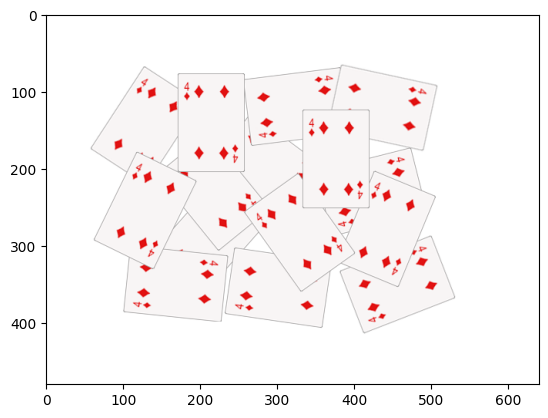

In [3]:
img_src = cv2.cvtColor(cv2.imread("data/cards.png"), cv2.COLOR_BGR2RGB)
plt.imshow(img_src);

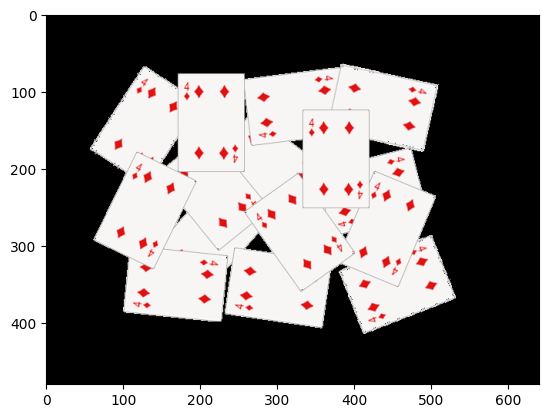

In [4]:
# Change the background from white to black, since that will help later to extract
# better results during the use of Distance Transform
img = img_src.copy()
img[np.all(img == 255, axis=2)] = 0

plt.imshow(img);

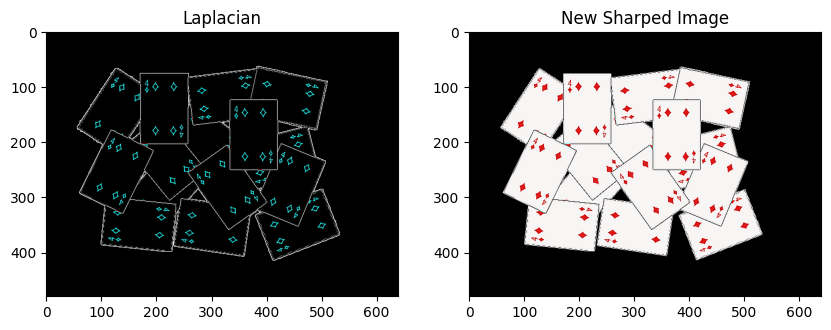

In [5]:
# Create a kernel that we will use to sharpen our image
# an approximation of second derivative, a quite strong kernel
kernel = np.array(
    [[  1,  1,  1],
     [  1, -8,  1],
     [  1,  1,  1]], dtype=np.float32)
# do the laplacian filtering as it is
# well, we need to convert everything in something more deeper then CV_8U
# because the kernel has some negative values,
# and we can expect in general to have a Laplacian image with negative values
# BUT a 8bits unsigned int (the one we are working with) can contain values from 0 to 255
# so the possible negative number will be truncated
imgLaplacian = cv2.filter2D(img, cv2.CV_32F, kernel)
sharp = np.float32(img)
imgResult = sharp - imgLaplacian

# convert back to 8bits gray scale
imgResult = np.clip(imgResult, 0, 255)
imgResult = imgResult.astype('uint8')
imgLaplacian = np.clip(imgLaplacian, 0, 255)
imgLaplacian = np.uint8(imgLaplacian)

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(imgLaplacian)
plt.title('Laplacian')
plt.subplot(122)
plt.imshow(imgResult)
plt.title('New Sharped Image');

### Бинаризация изображения

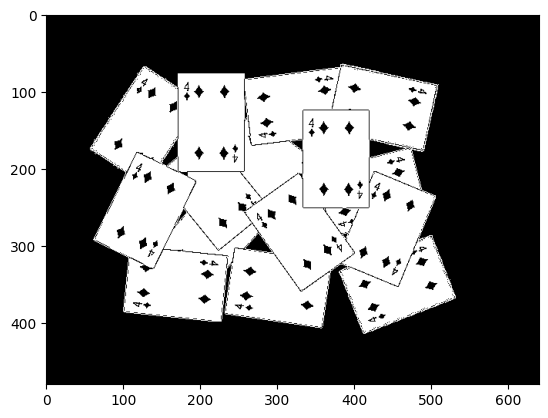

In [6]:
# Create binary image from source image
bw = cv2.cvtColor(imgResult, cv2.COLOR_BGR2GRAY)
_, bw = cv2.threshold(bw, 40, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
plt.imshow(bw, cmap="Greys_r");

### Distance transform

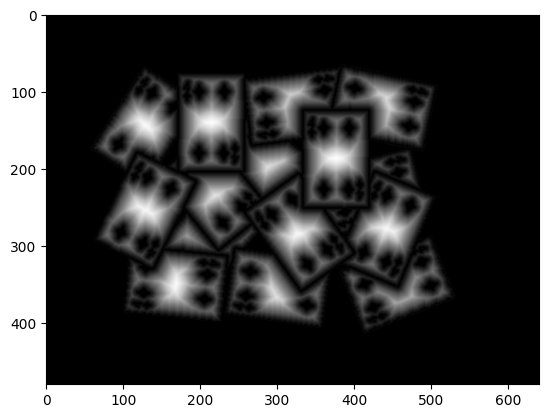

In [7]:
# Perform the distance transform algorithm
dist = cv2.distanceTransform(bw, cv2.DIST_L2, 3)
# Normalize the distance image for range = {0.0, 1.0}
# so we can visualize and threshold it
cv2.normalize(dist, dist, 0, 1.0, cv2.NORM_MINMAX)
plt.imshow(dist, cmap="Greys_r");

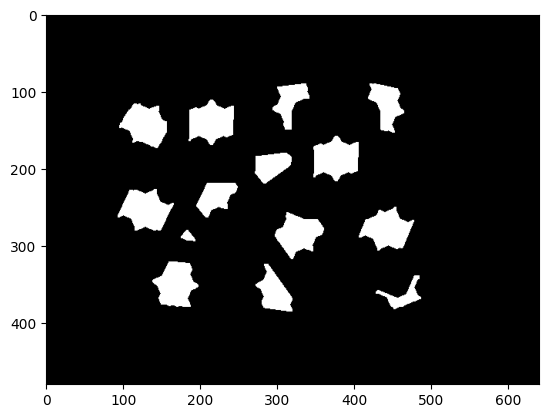

In [8]:
# Threshold to obtain the peaks
# This will be the markers for the foreground objects
_, dist = cv2.threshold(dist, 0.4, 1.0, cv2.THRESH_BINARY)
# Dilate a bit the dist image
kernel1 = np.ones((3,3), dtype=np.uint8)
dist = cv2.dilate(dist, kernel1)
plt.imshow(dist, cmap="Greys_r");

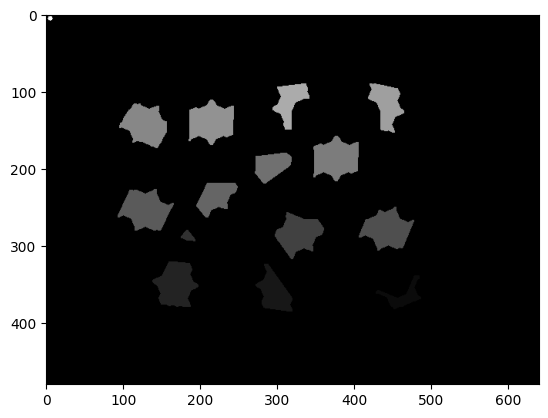

In [9]:
# Create the CV_8U version of the distance image
# It is needed for findContours()
dist_8u = dist.astype('uint8')
# Find total markers
contours, _ = cv2.findContours(dist_8u, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# Create the marker image for the watershed algorithm
markers = np.zeros(dist.shape, dtype=np.int32)
# Draw the foreground markers
for i in range(len(contours)):
    cv2.drawContours(
        markers,   # image
        contours,  # contours list
        i,         # contour index to draw
        (i+1),     # color (fill value)
        -1,        # thickness (if negative - fill the contour)
    )
# Draw the background marker
cv2.circle(
    markers,        # image
    (5,5),          # center
    3,              # radius
    (255,255,255),  # color
    -1,             # thickness (if negative - fill)
)

markers_8u = (markers * 10).astype('uint8')
plt.imshow(markers_8u, cmap="Greys_r");

### Алгоритм Watershed

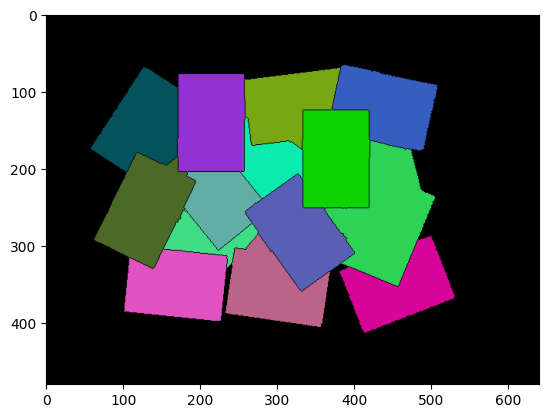

In [10]:
# Perform the watershed algorithm
cv2.watershed(imgResult, markers)

mark = markers.astype('uint8')
mark = cv2.bitwise_not(mark)
# uncomment this if you want to see how the mark
# image looks like at that point
# plt.imshow(mark)
# Generate random colors
colors = []
for contour in contours:
    colors.append((rng.randint(0,256), rng.randint(0,256), rng.randint(0,256)))
# Create the result image
dst = np.zeros((markers.shape[0], markers.shape[1], 3), dtype=np.uint8)
# Fill labeled objects with random colors
for i in range(markers.shape[0]):
    for j in range(markers.shape[1]):
        index = markers[i,j]
        if index > 0 and index <= len(contours):
            dst[i,j,:] = colors[index-1]

# Visualize the final image
plt.imshow(dst);

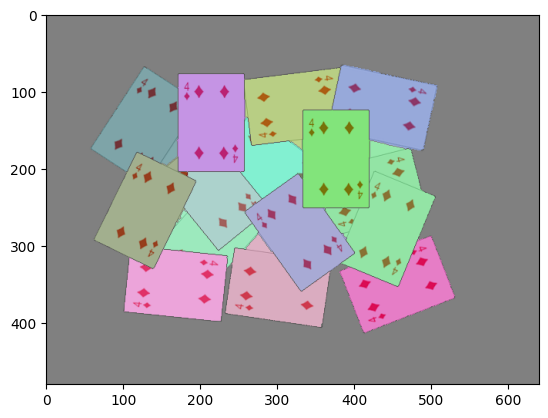

In [11]:
blended = cv2.addWeighted(img_src, 0.5, dst, 0.5, 0.0)
plt.imshow(blended);

# Домашнее задание: подсчет количества пальцев

**Это оцениваемое ДЗ**

Вам предлагается реализовать алгоритм, подсчитывающий количество пальцев.

Один из возможных вариантов решения:
- Получить бинаризованное изображение и найти контур руки;
- Построить выпуклый контур функцией `cv2.convexHull` - https://docs.opencv.org/3.4/d7/d1d/tutorial_hull.html
- Найти дефекты выпуклости контура функцией [`cv2.convexityDefects`](https://docs.opencv.org/3.4/d3/dc0/group__imgproc__shape.html#gada4437098113fd8683c932e0567f47ba)
- После некоторой фильтрации дефектов, их число будет напрямую коррелировать с числом пальцев.

**Требования:**
1. Продемонстрируйте работоспособность алгоритма на любом числе пальцев (от 0 до 5).
2. Используйте фото своей руки для демонстрации (предложенное фото лишь для отладки).

## Отладка

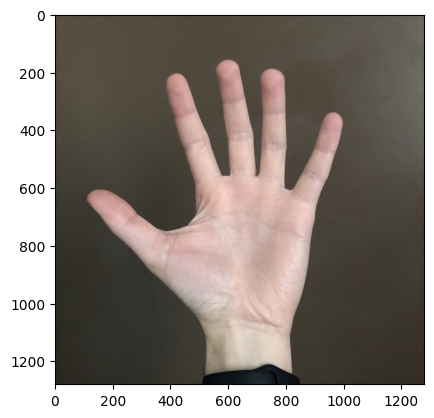

In [12]:
def load_image(img_path):
    '''Load original image'''
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    return img
    
img = load_image("data/hand.jpg")
plt.imshow(img)

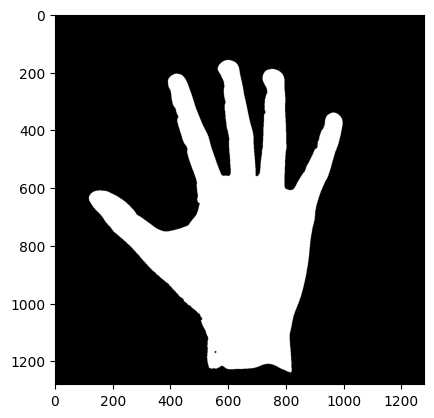

In [13]:
def create_binary_image(img):
    '''Create binary image from source image'''
    img_grayscale = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(img_grayscale, (15, 15), 0)
    _, img_binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
    return img_binary

img_binary = create_binary_image(img)
plt.imshow(img_binary, cmap="Greys_r")

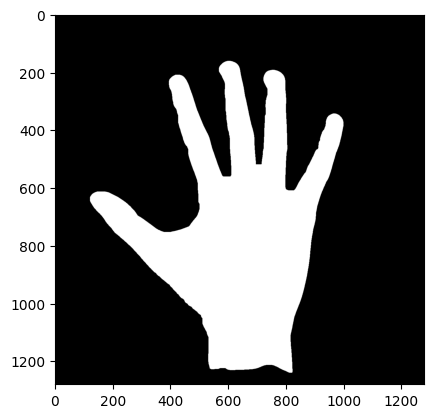

In [14]:
def apply_morphological_operations(binary_img, kernel_size=(10,10)):
    '''Apply dilation and erosion to a binary image'''
    kernel = np.ones(kernel_size, np.uint8)
    img_binary_filtered = binary_img.copy()
    img_binary_filtered = cv2.erode(img_binary_filtered, kernel, iterations=1)
    img_binary_filtered = cv2.dilate(img_binary_filtered, kernel, iterations=1)
    img_binary_filtered = cv2.dilate(img_binary_filtered, kernel, iterations=2)
    img_binary_filtered = cv2.erode(img_binary_filtered, kernel, iterations=2)
    return img_binary_filtered

img_binary_filtered = apply_morphological_operations(img_binary)
plt.imshow(img_binary_filtered, cmap="Greys_r")

Total contours: 1


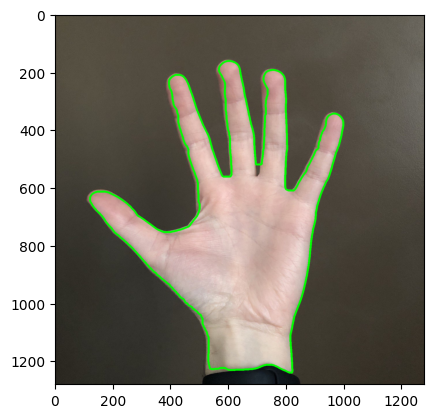

In [15]:
def find_contours(binary_image):
    '''Find contours on a binary image'''
    contours, _ = cv2.findContours(
        binary_image,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )
    return contours

contours = find_contours(img_binary_filtered)
print(f'Total contours: {len(contours)}')

img_countours = img.copy()
img_countours = cv2.drawContours(img_countours, contours, -1, (0,255,0), 5)
plt.imshow(img_countours)

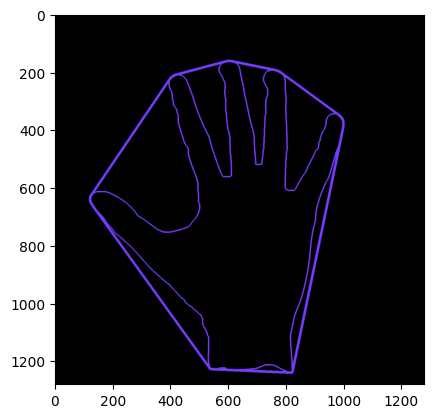

In [16]:
def find_hulls(contours, returnPoints=True):
    '''Find hulls using contours'''
    hull_list = []
    for contour in contours:
        hull = cv2.convexHull(contour, returnPoints=returnPoints)
        hull_list.append(hull)
    return hull_list

hulls = find_hulls(contours, returnPoints=True)

# Draw contour + hull result
# drawing = img.copy()
drawing = np.zeros((img.shape[0], img.shape[1], 3), dtype=np.uint8)

for i in range(len(hulls)):
    color = (rng.randint(0,256), rng.randint(0,256), rng.randint(0,256))
    cv2.drawContours(drawing, contours, i, color, thickness=3)
    cv2.drawContours(drawing, hulls, i, color, thickness=8)

# Show
plt.imshow(drawing)

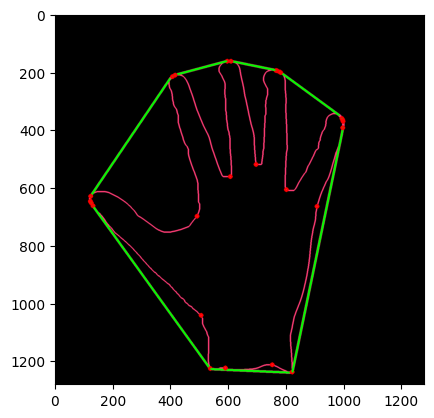

In [17]:
def find_defects(contour):
    '''Find defects'''
    hull = cv2.convexHull(contour, returnPoints=False)
    defects = cv2.convexityDefects(contour, hull)
    return defects

contour =  contours[0] 
if len(contours) > 1:
    print(f'Warning! Number of contours found: {len(contours)}. Using the biggest')
    contour = max(contours, key=lambda x: x.shape[0])

defects = find_defects(contour)

defect_img = drawing.copy()
for i in range(defects.shape[0]):
    s, e, f, d = defects[i, 0]
    start = tuple(contour[s][0])
    end = tuple(contour[e][0])
    far = tuple(contour[f][0])

    # Draw defect
    cv2.line(defect_img, start, end, [0, 255, 0], 5)
    cv2.circle(defect_img, far, 5, [0, 0, 255], 5)

plt.imshow(cv2.cvtColor(defect_img, cv2.COLOR_BGR2RGB))
plt.show()

In [18]:
def calculate_angle(start, end, far):
    '''Calculate angle between fingers'''
    a = np.sqrt((end[0] - start[0])**2 + (end[1] - start[1])**2)
    b = np.sqrt((far[0] - start[0])**2 + (far[1] - start[1])**2)
    c = np.sqrt((end[0] - far[0])**2 + (end[1] - far[1])**2)

    angle = np.arccos((b**2 + c**2 - a**2) / (2 * b * c)) * 180 / np.pi

    return angle

def count_fingers_from_defects(defects, contour):
    if defects is None:
        return 0
    
    finger_count = 0

    for i in range(defects.shape[0]):
        s, e, f, d = defects[i, 0]
        start = tuple(contour[s][0])
        end = tuple(contour[e][0])
        far = tuple(contour[f][0])
        
        angle = calculate_angle(start, end, far)
        
        # Filetring defects
        if angle < 100 and d > 5000:  # d - depth of defect
            finger_count += 1

    return finger_count + 1 # thumb

fingers_number = count_fingers_from_defects(defects, contour)
print(f'Total fingers: {fingers_number}')

Total fingers: 5


## Проверка на других фото

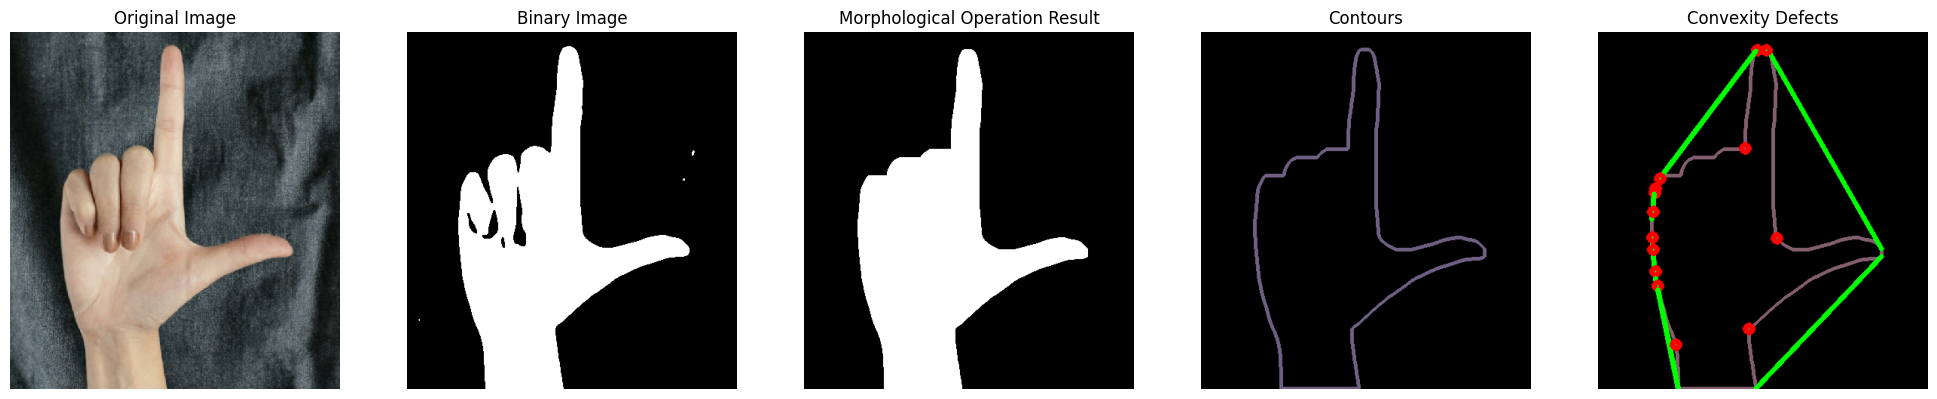

Total fingers: 2


In [19]:
def calculate_fingers(image_path, show_images=False):
    image = load_image(image_path)
    binary = create_binary_image(image)
    morphology = apply_morphological_operations(binary)
    contours = find_contours(morphology)
    contour = contours[0]
    if len(contours) > 1:
        print(f'Warning! Number of contours found: {len(contours)}. Using the biggest')
        contour = max(contours, key=lambda x: x.shape[0])
    defects = find_defects(contour)
    fingers = count_fingers_from_defects(defects, contour)

    if show_images:
        fig, axes = plt.subplots(1, 5, figsize=(20, 4))  # 1 row, 5 columns
        
        # Original Image
        axes[0].imshow(image)
        axes[0].set_title("Original Image")
        axes[0].axis('off')
        
        # Binary Image
        axes[1].imshow(binary, cmap="Greys_r")
        axes[1].set_title("Binary Image")
        axes[1].axis('off')
        
        # Morphology Image
        axes[2].imshow(morphology, cmap="Greys_r")
        axes[2].set_title("Morphological Operation Result")
        axes[2].axis('off')
        
        # Contour Drawing
        drawing = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8) 
        for i in range(len(contours)): 
            color = (rng.randint(0,256), rng.randint(0,256), rng.randint(0,256))
            cv2.drawContours(drawing, contours, i, color, thickness=3)
            
        axes[3].imshow(drawing)
        axes[3].set_title("Contours")
        axes[3].axis('off')
        
        # Defects Drawing
        defect_img = drawing.copy()
        if defects is not None and defects.size > 0: # Check if defects exist and are not empty
            for i in range(defects.shape[0]):
                s, e, f, d = defects[i, 0]
                start = tuple(contour[s][0])
                end = tuple(contour[e][0])
                far = tuple(contour[f][0])

                # Draw defect
                cv2.line(defect_img, start, end, [0, 255, 0], 5)
                cv2.circle(defect_img, far, 5, [0, 0, 255], 5)

        axes[4].imshow(cv2.cvtColor(defect_img, cv2.COLOR_BGR2RGB))
        axes[4].set_title("Convexity Defects")
        axes[4].axis('off')

        plt.tight_layout()
        plt.show()

    return fingers

image_path = "data/hands/hand.png"
fingers_number = calculate_fingers(image_path, show_images=True) 
print(f'Total fingers: {fingers_number}')